# CatBoost: hydropower unit commitment

**Group number:** TODO  
**Full names and student IDs:** TODO  
**Kaggle team name:** TODO

This notebook builds **14 binary CatBoost classifiers**, one per generating unit.
Each training row represents one case and one horizon hour. Models see all reservoirs'
initial conditions, supplied hourly planning inputs, whole-week context, and local
features derived from the supplied topology. Predictions are mapped explicitly back
to the 2352 target columns. Separate models are an initial modeling choice, not a
claim that they outperform a shared classifier.

All required code is included here. Install `requirements.txt` yourself, select the
project `.venv` kernel, then run cells from the top. Nothing is installed or downloaded
by this notebook. Training is opt-in via `RUN_MODE` in the next cell.

| Mode | What runs |
|---|---|
| `check` (default) | Input audits, feature construction on representative cases, alignment checks; no training |
| `smoke` | Small training/validation subsets, 40 trees per generator; diagnostics only |
| `validate` | Full chronological development folds with early stopping and interpretation |
| `holdout` | Refit pre-2022 data with a frozen configuration; evaluate 2022 once, without early stopping |
| `submit` | Refit all labeled cases with the frozen configuration and export the 725 test predictions |

After `validate`, copy the displayed configuration into `SELECTED_CONFIG`. It contains
parameters and 14 tree counts, not learned data. `holdout` and `submit` use that exact
configuration and rebuild from raw data; neither depends on saved models or helper files.
Restart the kernel and run from the top when changing modes. Each training run writes
to a new timestamped directory under `outputs/catboost/`.

**Status:** Data processing and export checks can run without CatBoost. Training time
and predictive quality are unmeasured until you run training. No 0.995 score or grade
is guaranteed. Whole-notebook runtime must remain below the course's 12-hour limit.

In [29]:
from pathlib import Path
from datetime import datetime, timezone
from importlib import metadata
from time import perf_counter
import gc
import hashlib
import json
import platform
import re

import numpy as np
import pandas as pd
import yaml
from IPython.display import display

ROOT = Path.cwd()
RUN_MODE = "submit"  # check, smoke, validate, holdout, submit
SEED = 42
THREADS = 4
HOURS = 168
FEATURE_VERSION = "hydro-context-v1"
FOLDS = [("2020-01-01", "2021-01-01"), ("2021-01-01", "2022-01-01")]
HOLDOUT_START = pd.Timestamp("2022-01-01", tz="UTC")
EARLY_STOPPING = 100
MAX_ITERATIONS = 1500
BASE_PARAMETERS = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "depth": 7,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_strength": 0.5,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "border_count": 128,
    "task_type": "CPU",
}
# Paste the complete dictionary printed by a completed validate run here.
SELECTED_CONFIG = {'feature_version': 'hydro-context-v1', 'feature_signature': '4d09eef00a583fad18e6d8cd0f361f2d06a4e9fcfecc5e904dba743f664df16e', 'seed': 42, 'parameters': {'loss_function': 'Logloss', 'eval_metric': 'AUC', 'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 5.0, 'random_strength': 0.5, 'bootstrap_type': 'Bernoulli', 'subsample': 0.8, 'border_count': 128, 'task_type': 'CPU'}, 'iterations': {'Hogga_G1': 217, 'Tokke_G1': 91, 'Tokke_G2': 484, 'Tokke_G3': 229, 'Tokke_G4': 123, 'Lio_G1': 147, 'Byrte_G1': 173, 'Vinje_G1': 373, 'Vinje_G2': 332, 'Vinje_G3': 231, 'Haukeli_G1': 23, 'Songa_G1': 486, 'Kjela_G1': 212, 'Vesle Kjela_G1': 133}}

if RUN_MODE not in {"check", "smoke", "validate", "holdout", "submit"}:
    raise ValueError("Unknown RUN_MODE.")
if not (ROOT / "prediction_mapping.csv").is_file():
    raise FileNotFoundError("Run the notebook from the project root with the supplied data present.")
if not 1 <= THREADS <= 4:
    raise ValueError("Use between 1 and 4 CPU threads for the course reproduction budget.")
NOTEBOOK_STARTED = perf_counter()
VERSIONS = {"python": platform.python_version()}
for package in ("numpy", "pandas", "PyYAML", "catboost", "scikit-learn", "matplotlib"):
    try:
        VERSIONS[package] = metadata.version(package)
    except metadata.PackageNotFoundError:
        VERSIONS[package] = "not installed"
print("Mode:", RUN_MODE)
print("Package versions:", VERSIONS)
if RUN_MODE != "check":
    missing = [p for p in ("catboost", "scikit-learn") if VERSIONS[p] == "not installed"]
    if missing:
        raise ImportError(f"Install requirements.txt into this kernel's environment first: {missing}")

Mode: submit
Package versions: {'python': '3.14.7', 'numpy': '2.5.3', 'pandas': '3.0.6', 'PyYAML': '6.0.3', 'catboost': '1.2.10', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2'}


## 1. Case definitions and target schema

`Run No` is an identifier, not a feature. `total_calculation_time` is optimizer output
and is excluded. Target columns are parsed by name rather than assumed reshape order.
The sample submission provides the exact test IDs and output ordering.

In [30]:
RAW_FILES = {
    "labels": ROOT / "data/kernel/Unit_commitment_decisions.csv",
    "mapping": ROOT / "prediction_mapping.csv",
    "template": ROOT / "sample_submission.csv",
    "prices": ROOT / "data/kernel/Historical_day_ahead_price_2015_2025.csv",
    "inflows": ROOT / "data/kernel/Historical_inflow_1958_2025.csv",
    "volumes": ROOT / "data/kernel/Historical_volume_2015_2024.csv",
    "water_values": ROOT / "data/kernel/Synthetic_water_value_2015_2024.csv",
    "min_flow": ROOT / "data/extended/Constraint_min_flow.csv",
    "min_volume": ROOT / "data/extended/Constraint_min_volume.csv",
    "topology": ROOT / "data/extended/Tokke_Vinje_topology.yaml",
}
for path in RAW_FILES.values():
    if not path.is_file():
        raise FileNotFoundError(path)
train_cases = pd.read_csv(RAW_FILES["labels"])
test_cases = pd.read_csv(RAW_FILES["mapping"])
template = pd.read_csv(RAW_FILES["template"])
for cases in (train_cases, test_cases):
    cases["starttime"] = pd.to_datetime(cases["starttime"], utc=True, errors="raise")
    if cases.empty or cases["Run No"].isna().any() or not cases["Run No"].is_unique:
        raise ValueError("Cases require nonempty, unique, nonmissing Run No values.")
    if cases["starttime"].isna().any() or not cases["starttime"].is_unique:
        raise ValueError("Case start times must be unique and nonmissing.")
    if not cases["starttime"].equals(cases["starttime"].dt.normalize()):
        raise ValueError("Expected midnight UTC case starts.")
if not template["Run No"].is_unique or set(template["Run No"]) != set(test_cases["Run No"]):
    raise ValueError("Submission IDs must match the test mapping exactly.")
if set(train_cases["Run No"]) & set(test_cases["Run No"]):
    raise ValueError("Training and test case IDs overlap.")
train_cases = train_cases.sort_values("starttime").reset_index(drop=True)
test_cases = test_cases.set_index("Run No").loc[template["Run No"]].reset_index()
LABELS = template.columns.drop("Run No").tolist()
TARGETS = {}
for position, name in enumerate(LABELS):
    match = re.fullmatch(r"result_committed_(.+_G\d+)_t(\d+)", name)
    if match is None:
        raise ValueError(f"Unexpected target column: {name}")
    generator, hour = match.group(1), int(match.group(2))
    if hour in TARGETS.setdefault(generator, {}):
        raise ValueError(f"Duplicate generator/hour: {generator}, {hour}")
    TARGETS[generator][hour] = (name, position)
GENERATORS = list(TARGETS)
if len(GENERATORS) != 14 or len(LABELS) != 14 * HOURS:
    raise ValueError("Expected 14 generators and 2352 targets.")
for generator in GENERATORS:
    if set(TARGETS[generator]) != set(range(HOURS)):
        raise ValueError(f"Incomplete horizon for {generator}")
TARGET_COLUMNS = {g: [TARGETS[g][h][0] for h in range(HOURS)] for g in GENERATORS}
TARGET_POSITIONS = {g: [TARGETS[g][h][1] for h in range(HOURS)] for g in GENERATORS}
if not set(LABELS).issubset(train_cases) or not train_cases[LABELS].isin([0, 1]).all().all():
    raise ValueError("All target columns must be present with binary, nonmissing labels.")

def labels_for(cases, generator):
    return cases[TARGET_COLUMNS[generator]].to_numpy(dtype=np.uint8).reshape(-1)

all_starts = pd.DatetimeIndex(pd.concat([train_cases["starttime"], test_cases["starttime"]]))
FIRST_START = all_starts.min()
LAST_END = all_starts.max() + pd.Timedelta(hours=HOURS)
print(f"{len(train_cases)} training cases; {len(test_cases)} test cases; {len(LABELS)} targets")
display(pd.DataFrame({"generator": GENERATORS,
    "training_on_fraction": [float(labels_for(train_cases, g).mean()) for g in GENERATORS]}))

2922 training cases; 725 test cases; 2352 targets


,generator,training_on_fraction
0,Hogga_G1,0.594560
1,Tokke_G1,0.670991
2,Tokke_G2,0.478354
3,Tokke_G3,0.564262
4,Tokke_G4,0.498195
5,Lio_G1,0.746533
6,Byrte_G1,0.542003
7,Vinje_G1,0.485386
8,Vinje_G2,0.420368
9,Vinje_G3,0.259149


## 2. Raw inputs, units, and topology

Prices and inflows cover the planning horizon; volumes are taken **only at the case
start**, and terminal water values **only at start + 168 hours**. Environmental limits
are taken within the horizon. Every lookup is timestamp-based in UTC. No interpolation
or silent zero-filling is used for missing records. The later quarter-hour price
records outside the task's required date range are not resampled into our data.

We use the provided YAML reservoir capacities to derive filling fractions, and its
connections to identify each plant's immediate supplying reservoirs, traversing
intake tunnels. These local aggregates are descriptive features, not a hydraulic
simulator or proof of physical feasibility. All reservoirs also remain available
individually to every generator model.

In [31]:
def read_timeseries(key):
    frame = pd.read_csv(RAW_FILES[key])
    dates = pd.to_datetime(frame.pop("date"), utc=True, errors="raise")
    if dates.isna().any() or dates.duplicated().any():
        raise ValueError(f"Invalid or duplicate timestamps in {key}")
    frame.index = pd.DatetimeIndex(dates, name="date")
    frame = frame.sort_index().loc[FIRST_START:LAST_END]
    frame = frame.apply(pd.to_numeric, errors="raise").astype(np.float32)
    if frame.empty or not np.isfinite(frame.to_numpy()).all():
        raise ValueError(f"Empty or nonfinite input: {key}")
    return frame

tables = {key: read_timeseries(key) for key in
          ("prices", "inflows", "volumes", "water_values", "min_flow", "min_volume")}
if list(tables["prices"].columns) != ["Day-ahead price (EUR/MWh)"]:
    raise ValueError("Unexpected electricity price column.")
with RAW_FILES["topology"].open(encoding="utf-8") as stream:
    topology = yaml.safe_load(stream)
RESERVOIRS = list(tables["volumes"].columns)
if len(RESERVOIRS) != 17:
    raise ValueError("Expected 17 reservoirs.")
for key in ("inflows", "water_values"):
    if not set(RESERVOIRS).issubset(tables[key].columns):
        raise ValueError(f"Missing reservoir columns in {key}")
CAPACITY = {r: float(topology["model"]["reservoir"][r]["max_vol"]) for r in RESERVOIRS}
if any(v <= 0 for v in CAPACITY.values()):
    raise ValueError("Reservoir capacities must be positive.")
for key in ("inflows", "volumes", "min_flow", "min_volume"):
    if (tables[key].to_numpy() < 0).any():
        raise ValueError(f"Unexpected negative water quantity in {key}")

hourly_required = pd.date_range(FIRST_START, LAST_END, freq="h", inclusive="left")
for key in ("prices", "inflows", "min_flow", "min_volume"):
    used = tables[key].loc[tables[key].index < LAST_END]
    if not used.index.equals(hourly_required):
        raise ValueError(f"{key} must contain exactly one record per required hour.")
for key, timestamps in (("volumes", all_starts),
                        ("water_values", all_starts + pd.Timedelta(hours=HOURS))):
    if not timestamps.difference(tables[key].index).empty:
        raise ValueError(f"Missing required daily records in {key}")

connections = topology["connections"]
def supplying_reservoirs(name, kind, visited=None):
    visited = set() if visited is None else visited
    node = (kind, name)
    if node in visited:
        raise ValueError("Cycle in intake topology.")
    if kind == "reservoir":
        return {name}
    result = set()
    for edge in connections:
        if edge["to"] == name and edge["to_type"] == kind and edge["from_type"] in {"reservoir", "tunnel"}:
            result |= supplying_reservoirs(edge["from"], edge["from_type"], visited | {node})
    return result

FEEDERS = {}
for generator in GENERATORS:
    plants = [e["to"] for e in connections if e["from"] == generator
              and e["from_type"] == "generator" and e["to_type"] == "plant"]
    if len(plants) != 1:
        raise ValueError(f"Expected one plant for {generator}")
    FEEDERS[generator] = sorted(supplying_reservoirs(plants[0], "plant"))
    if not FEEDERS[generator] or not set(FEEDERS[generator]).issubset(RESERVOIRS):
        raise ValueError(f"Unknown supplying reservoirs for {generator}")
display(pd.DataFrame({"generator": GENERATORS,
                      "intake_reservoirs": [", ".join(FEEDERS[g]) for g in GENERATORS]}))
display(pd.DataFrame([{"input": k, "rows_in_task_range": len(v), "columns": len(v.columns),
                       "start": str(v.index.min()), "end": str(v.index.max())}
                      for k, v in tables.items()]))

,generator,intake_reservoirs
0,Hogga_G1,Bandak
1,Tokke_G1,Vinjevatn
2,Tokke_G2,Vinjevatn
3,Tokke_G3,Vinjevatn
4,Tokke_G4,Vinjevatn
5,Lio_G1,Byrtevatn
6,Byrte_G1,Botnedalsvatn
7,Vinje_G1,Vaamarvatn
8,Vinje_G2,Vaamarvatn
9,Vinje_G3,Vaamarvatn


,input,rows_in_task_range,columns,start,end
0,prices,87673,1,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
1,inflows,87673,18,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
2,volumes,3654,17,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
3,water_values,3654,17,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
4,min_flow,87673,6,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00
5,min_volume,87673,3,2015-01-01 00:00:00+00:00,2025-01-01 00:00:00+00:00


## 3. Feature construction

Each matrix has one row per `(case, horizon_hour)`, in that order. The design contains:

- Hour, weekday, annual seasonality, horizon position, and distance to horizon end.
- Hourly price, nearby prices within the same planning week, daily and weekly price
  summaries, price rank, and average prices before/after the current hour.
- All reservoirs' initial volumes/filling fractions and terminal water values;
  hourly price minus each terminal water value.
- Hourly inflows, cumulative and remaining inflow volumes, and weekly means.
- Hourly environmental limits, initial storage margins, and weekly maxima of limits.
- Generator-specific intake aggregates, including price relative to capacity-weighted
  terminal water value and available-water proxies. These proxies omit dispatch and
  routed releases and are not forecasts of realized storage.

All summaries are derived from the **supplied inputs of the same planning case**.
No feature learns from labels or needs fitting, and no case ID or absolute year is
used. Features use float32; only one generator model is trained at a time, avoiding
an expanded 6.9-million-row matrix with repeated reservoir features.

In [32]:
def lookup(key, timestamps, columns=None):
    frame = tables[key] if columns is None else tables[key][columns]
    selected = frame.reindex(pd.DatetimeIndex(timestamps))
    if selected.isna().any().any():
        raise ValueError(f"Missing values while looking up {key}")
    return selected.to_numpy(dtype=np.float32)

def feature_matrix(cases):
    starts = pd.DatetimeIndex(cases["starttime"])
    if len(starts) == 0:
        raise ValueError("Cannot construct features for zero cases.")
    n = len(starts)
    # Use datetime arithmetic rather than assuming pandas timestamps use nanoseconds.
    timestamps = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
        np.tile(np.arange(HOURS), n), unit="h")
    price = lookup("prices", timestamps).reshape(n, HOURS)
    initial = lookup("volumes", starts, RESERVOIRS)
    terminal = lookup("water_values", starts + pd.Timedelta(hours=HOURS), RESERVOIRS)
    inflows = lookup("inflows", timestamps).reshape(n, HOURS, -1)
    features = {}

    def add(name, values):
        values = np.asarray(values, dtype=np.float32)
        if values.shape == (n,):
            values = np.repeat(values, HOURS)
        elif values.shape == (n, HOURS):
            values = values.reshape(-1)
        if values.shape != (n * HOURS,) or not np.isfinite(values).all():
            raise ValueError(f"Invalid feature {name}: {values.shape}")
        features[name] = values

    h = np.tile(np.arange(HOURS, dtype=np.float32), n)
    add("horizon_hour", h)
    add("hours_remaining", HOURS - 1 - h)
    add("hour_of_day", timestamps.hour.to_numpy())
    add("day_of_week", timestamps.dayofweek.to_numpy())
    add("month", timestamps.month.to_numpy())
    add("day_of_year_sin", np.sin(2 * np.pi * timestamps.dayofyear.to_numpy() / 365.25))
    add("day_of_year_cos", np.cos(2 * np.pi * timestamps.dayofyear.to_numpy() / 365.25))
    add("price", price)
    for stat, values in (("mean", price.mean(1)), ("std", price.std(1)),
                         ("min", price.min(1)), ("max", price.max(1))):
        add(f"price_week_{stat}", values)
    add("price_minus_week_mean", price - price.mean(1, keepdims=True))
    add("price_week_rank", pd.DataFrame(price).rank(axis=1, pct=True).to_numpy())
    daily = price.reshape(n, 7, 24)
    for stat, values in (("mean", daily.mean(2)), ("min", daily.min(2)), ("max", daily.max(2))):
        add(f"price_day_{stat}", np.repeat(values, 24, axis=1))
    add("price_prefix_mean", price.cumsum(1) / np.arange(1, HOURS + 1))
    add("price_suffix_mean", price[:, ::-1].cumsum(1)[:, ::-1] / np.arange(HOURS, 0, -1))
    # Clip at the case boundary, not at the global dataset boundary.
    for offset in (-24, -6, -1, 1, 6, 24):
        add(f"price_offset_{offset:+d}", price[:, np.clip(np.arange(HOURS) + offset, 0, HOURS - 1)])
    for j, reservoir in enumerate(RESERVOIRS):
        add(f"initial_volume__{reservoir}", initial[:, j])
        add(f"initial_fraction__{reservoir}", initial[:, j] / CAPACITY[reservoir])
        add(f"terminal_value__{reservoir}", terminal[:, j])
        add(f"price_minus_value__{reservoir}", price - terminal[:, j, None])
    for j, name in enumerate(tables["inflows"].columns):
        flow = inflows[:, :, j]
        cumulative = flow.cumsum(1) * (3600 / 1e6)
        add(f"inflow__{name}", flow)
        add(f"inflow_week_mean__{name}", flow.mean(1))
        add(f"inflow_cumulative_Mm3__{name}", cumulative)
        add(f"inflow_remaining_Mm3__{name}", cumulative[:, -1:] - cumulative)
    for key in ("min_flow", "min_volume"):
        limits = lookup(key, timestamps).reshape(n, HOURS, -1)
        for j, name in enumerate(tables[key].columns):
            add(f"{key}__{name}", limits[:, :, j])
            add(f"{key}_week_max__{name}", limits[:, :, j].max(1))
            if key == "min_volume":
                add(f"initial_margin_to_min__{name}", initial[:, RESERVOIRS.index(name), None] - limits[:, :, j])
    return pd.DataFrame(features, dtype=np.float32)

def generator_features(base, generator):
    # Copy only one generator's matrix at a time; never materialize all 14 together.
    X = base.copy()
    feeders = FEEDERS[generator]
    capacity = sum(CAPACITY[r] for r in feeders)
    total_initial = sum(base[f"initial_volume__{r}"] for r in feeders)
    value = sum(base[f"terminal_value__{r}"] * CAPACITY[r] for r in feeders) / capacity
    cumulative = sum(base[f"inflow_cumulative_Mm3__{r}"] for r in feeders)
    remaining = sum(base[f"inflow_remaining_Mm3__{r}"] for r in feeders)
    X["local_initial_fraction"] = total_initial / capacity
    X["local_terminal_value_capacity_weighted"] = value
    X["local_price_minus_terminal_value"] = base["price"] - value
    X["local_inflow"] = sum(base[f"inflow__{r}"] for r in feeders)
    X["local_cumulative_inflow_fraction"] = cumulative / capacity
    X["local_remaining_inflow_fraction"] = remaining / capacity
    X["local_available_water_proxy_fraction"] = (total_initial + cumulative + remaining) / capacity
    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Features must be finite.")
    return X.astype(np.float32, copy=False)

## 4. Chronological folds and executable data checks

For each development fold, training horizons end no later than the validation start.
Validation horizons also end before the next period starts. Never randomly split the
expanded hourly rows. The two default development folds evaluate 2020 and 2021.

2022 is reserved for evaluating a frozen candidate. It is not used for early stopping
or choosing tree counts. The deleted seasonal baseline previously scored 0.564993 on
2022; that historical result is not directly comparable to the development folds.
The notebook computes a fold-matched seasonal baseline during development evaluation.

In [33]:
def chronological_split(start, end):
    start, end = pd.Timestamp(start, tz="UTC"), pd.Timestamp(end, tz="UTC")
    if start >= end or end > HOLDOUT_START:
        raise ValueError("Development folds must end by the reserved holdout start.")
    horizon_end = train_cases["starttime"] + pd.Timedelta(hours=HOURS)
    fitting = train_cases.loc[horizon_end <= start].copy()
    validation = train_cases.loc[(train_cases["starttime"] >= start) & (horizon_end <= end)].copy()
    if fitting.empty or validation.empty:
        raise ValueError("Empty chronological fold.")
    if (fitting["starttime"] + pd.Timedelta(hours=HOURS)).max() > validation["starttime"].min():
        raise ValueError("Training and validation horizons overlap.")
    return fitting, validation

def even_sample(cases, maximum):
    indices = np.linspace(0, len(cases) - 1, min(maximum, len(cases)), dtype=int)
    return cases.iloc[indices].copy()

def assemble_predictions(cases, predictions):
    if set(predictions) != set(GENERATORS):
        raise ValueError("Predictions must cover all 14 generators.")
    values = np.empty((len(cases), len(LABELS)), dtype=np.float32)
    for generator in GENERATORS:
        probability = np.asarray(predictions[generator])
        if probability.shape != (len(cases), HOURS):
            raise ValueError(f"Wrong prediction shape for {generator}")
        values[:, TARGET_POSITIONS[generator]] = probability
    if not np.isfinite(values).all() or (values < 0).any() or (values > 1).any():
        raise ValueError("Predictions must be finite probabilities in [0, 1].")
    result = pd.DataFrame(values, columns=LABELS)
    result.insert(0, "Run No", cases["Run No"].to_numpy())
    return result

display(pd.DataFrame([{"validation_start": start, "validation_end_exclusive": end,
                       "training_cases": len(chronological_split(start, end)[0]),
                       "validation_cases": len(chronological_split(start, end)[1])}
                      for start, end in FOLDS]))
probe_cases = pd.concat([train_cases.iloc[[0, 1]], test_cases.iloc[[0, -1]]], ignore_index=True)
probe = feature_matrix(probe_cases)
probe_single = feature_matrix(probe_cases.iloc[[1]])
np.testing.assert_allclose(probe.iloc[HOURS:2 * HOURS].to_numpy(), probe_single.to_numpy())
for i, start in enumerate(probe_cases["starttime"]):
    rows = slice(i * HOURS, (i + 1) * HOURS)
    times = pd.date_range(start, periods=HOURS, freq="h")
    np.testing.assert_allclose(probe.iloc[rows]["price"], lookup("prices", times).reshape(-1))
    for reservoir in RESERVOIRS:
        np.testing.assert_allclose(probe.iloc[rows][f"initial_volume__{reservoir}"], tables["volumes"].at[start, reservoir])
        np.testing.assert_allclose(probe.iloc[rows][f"terminal_value__{reservoir}"], tables["water_values"].at[start + pd.Timedelta(hours=HOURS), reservoir])
for g in GENERATORS:
    generator_features(probe, g)
    truth = labels_for(train_cases.iloc[:2], g).reshape(2, HOURS)
    np.testing.assert_array_equal(truth[:, [0, 24, 167]], train_cases.iloc[:2][[TARGET_COLUMNS[g][h] for h in (0, 24, 167)]])
roundtrip = assemble_predictions(train_cases.iloc[:2],
    {g: labels_for(train_cases.iloc[:2], g).reshape(2, HOURS) for g in GENERATORS})
np.testing.assert_array_equal(roundtrip[LABELS], train_cases.iloc[:2][LABELS])
FEATURE_NAMES = generator_features(probe, GENERATORS[0]).columns.tolist()
FEATURE_SIGNATURE = hashlib.sha256(json.dumps(FEATURE_NAMES).encode()).hexdigest()
if any(c in FEATURE_NAMES for c in ("Run No", "starttime", "total_calculation_time")):
    raise ValueError("Metadata leaked into predictors.")
bytes_per_case = HOURS * len(FEATURE_NAMES) * np.dtype("float32").itemsize
print(f"Data checks passed: {len(FEATURE_NAMES)} features per generator-hour.")
print(f"One full training feature matrix: approximately {len(train_cases) * bytes_per_case / 2**20:.0f} MiB.")
print("This is not peak memory: copies, CatBoost pools, and model state add overhead.")
del probe, probe_single, roundtrip

,validation_start,validation_end_exclusive,training_cases,validation_cases
0,2020-01-01,2021-01-01,1820,360
1,2021-01-01,2022-01-01,2186,359


Data checks passed: 193 features per generator-hour.
One full training feature matrix: approximately 361 MiB.
This is not peak memory: copies, CatBoost pools, and model state add overhead.


C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. U

## 5. Training, metrics, and interpretation helpers

Initial hyperparameters are explicit starting values, **not tuned values**. Development
uses binary log loss for fitting and per-generator AUC for early stopping. Overall
model selection uses **micro ROC-AUC across all targets**, which is not the mean of
per-generator AUCs. Probabilities are left unthresholded and no class weighting is
used. Constant-label training subsets receive an explicit constant-probability fallback.

The reference metric calls scikit-learn's `roc_auc_score(..., average="micro")`; the
same call is inlined below to keep this notebook independent of `kaggle_metric.py`.
Feature importance is predictive association, not a causal explanation. Results,
training curves, per-generator scores, run configuration, versions, input hashes,
and measured times are recorded. Interrupted runs remain marked incomplete.

In [34]:
def safe_auc(actual, predicted):
    from sklearn.metrics import roc_auc_score
    actual = np.asarray(actual).reshape(-1)
    if np.unique(actual).size < 2:
        return None
    return float(roc_auc_score(actual, np.asarray(predicted).reshape(-1)))

def evaluate(cases, predictions):
    from sklearn.metrics import roc_auc_score
    frame = assemble_predictions(cases, predictions)
    actual = cases[LABELS].to_numpy(dtype=np.uint8)
    predicted = frame[LABELS].to_numpy()
    overall = float(roc_auc_score(actual, predicted, average="micro"))
    detail = pd.DataFrame([{"generator": g,
        "auc": safe_auc(labels_for(cases, g), predictions[g]),
        "observed_on_fraction": float(labels_for(cases, g).mean()),
        "mean_prediction": float(predictions[g].mean())} for g in GENERATORS])
    return overall, detail, frame

def seasonal_predictions(fitting, validation):
    groups = fitting[LABELS].groupby(fitting["starttime"].dt.month).mean()
    if not set(validation["starttime"].dt.month).issubset(groups.index):
        raise ValueError("The seasonal reference lacks a validation month in training.")
    values = groups.loc[validation["starttime"].dt.month]
    return {g: values[TARGET_COLUMNS[g]].to_numpy(dtype=np.float32) for g in GENERATORS}

def write_json(path, payload):
    path.write_text(json.dumps(payload, indent=2, allow_nan=False), encoding="utf-8")

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def fit_and_predict(fitting, evaluation, parameters, iterations, folder, *, early_stop):
    from catboost import CatBoostClassifier
    started = perf_counter()
    folder.mkdir(parents=True, exist_ok=False)
    X_fit_base, X_eval_base = feature_matrix(fitting), feature_matrix(evaluation)
    feature_seconds = perf_counter() - started
    predicted, records, importance, curves = {}, [], [], {}
    for generator in GENERATORS:
        generator_started = perf_counter()
        X_fit = generator_features(X_fit_base, generator)
        X_eval = generator_features(X_eval_base, generator)
        if X_fit.columns.tolist() != FEATURE_NAMES or X_eval.columns.tolist() != FEATURE_NAMES:
            raise ValueError("Feature schema changed between data partitions.")
        y = labels_for(fitting, generator)
        limit = int(iterations[generator] if isinstance(iterations, dict) else iterations)
        if limit < 1:
            raise ValueError("Tree counts must be positive.")
        model = None
        if np.unique(y).size == 1:
            probability = np.full(len(evaluation) * HOURS, float(y[0]), dtype=np.float32)
            tree_count = 1
            constant = float(y[0])
            write_json(folder / f"{generator}_constant.json", {"probability": constant})
        else:
            constant = None
            model = CatBoostClassifier(**parameters, iterations=limit, random_seed=SEED,
                                      thread_count=THREADS, allow_writing_files=False)
            options = {"verbose": 100}
            if early_stop:
                y_eval = labels_for(evaluation, generator)
                # AUC is undefined for a one-class validation subset.
                if np.unique(y_eval).size == 2:
                    options.update(eval_set=(X_eval, y_eval),
                                   early_stopping_rounds=EARLY_STOPPING, use_best_model=True)
            print(f"Training {generator}: {len(y):,} hourly rows, at most {limit} trees", flush=True)
            model.fit(X_fit, y, **options)
            if list(model.classes_) != [0, 1]:
                raise ValueError("Unexpected CatBoost class order.")
            probability = model.predict_proba(X_eval, thread_count=THREADS)[:, 1].astype(np.float32)
            tree_count = int(model.tree_count_)
            model.save_model(str(folder / f"{generator}.cbm"))
            curves[generator] = model.get_evals_result()
            importance.extend({"generator": generator, "feature": name, "importance": float(value)}
                              for name, value in zip(FEATURE_NAMES, model.get_feature_importance(thread_count=THREADS)))
        predicted[generator] = probability.reshape(len(evaluation), HOURS)
        records.append({"generator": generator, "trees": tree_count,
                        "constant_probability": constant,
                        "seconds": perf_counter() - generator_started})
        pd.DataFrame(records).to_csv(folder / "training_progress.csv", index=False)
        del X_fit, X_eval, model
        gc.collect()
    pd.DataFrame(importance, columns=["generator", "feature", "importance"]).to_csv(folder / "feature_importance.csv", index=False)
    write_json(folder / "learning_curves.json", curves)
    write_json(folder / "timing.json", {"feature_seconds": feature_seconds,
                                       "total_seconds": perf_counter() - started})
    del X_fit_base, X_eval_base
    gc.collect()
    return predicted, records, importance

## 6. Run the selected mode

`check` stops short of all fitting. `smoke` uses evenly spaced **whole cases**, never
random hourly rows, and cannot produce a final submission or a frozen configuration.
Its score is a plumbing diagnostic, not a full-data performance estimate.

`validate` trains the default development folds and selects each generator's median
best tree count across folds. This is a starting refit rule, not a tuned search.
If many models reach the maximum tree count, inspect convergence before increasing
the budget. Freeze both parameters and tree counts before running `holdout`.

The frozen configuration must also preserve feature schema and random seed. Modifying
feature logic requires incrementing `FEATURE_VERSION` and revalidating. No holdout
score is used to update parameters or iterations automatically.

In [ ]:
RUN_DIRECTORY = None
run_summary = None
importance_rows = []
if RUN_MODE == "check":
    print("Check mode complete. No models trained and no submission written.")
else:
    if RUN_MODE in {"holdout", "submit"}:
        if not isinstance(SELECTED_CONFIG, dict):
            raise ValueError("Paste a completed validate run's configuration into SELECTED_CONFIG first.")
        if SELECTED_CONFIG.get("feature_version") != FEATURE_VERSION or SELECTED_CONFIG.get("feature_signature") != FEATURE_SIGNATURE:
            raise ValueError("Frozen configuration and current features do not match.")
        if SELECTED_CONFIG.get("seed") != SEED:
            raise ValueError("Use the same random seed as the frozen configuration.")
        if set(SELECTED_CONFIG.get("iterations", {})) != set(GENERATORS):
            raise ValueError("Frozen configuration must include tree counts for every generator.")
        if any(not isinstance(v, int) or v < 1 for v in SELECTED_CONFIG["iterations"].values()):
            raise ValueError("Frozen tree counts must be positive integers.")
        parameters = dict(SELECTED_CONFIG["parameters"])
        if parameters.get("task_type") != "CPU":
            raise ValueError("This notebook's reproducible configuration uses CPU training.")
    else:
        parameters = dict(BASE_PARAMETERS)

    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    RUN_DIRECTORY = ROOT / "outputs" / "catboost" / f"{stamp}_{RUN_MODE}"
    RUN_DIRECTORY.mkdir(parents=True, exist_ok=False)
    run_summary = {"status": "incomplete", "mode": RUN_MODE, "versions": VERSIONS,
        "seed": SEED, "threads": THREADS, "feature_version": FEATURE_VERSION,
        "feature_signature": FEATURE_SIGNATURE, "features": FEATURE_NAMES,
        "parameters": parameters, "folds": FOLDS,
        "maximum_iterations": MAX_ITERATIONS, "early_stopping_rounds": EARLY_STOPPING,
        "selected_configuration": SELECTED_CONFIG,
        "input_sha256": {k: file_hash(v) for k, v in RAW_FILES.items()}}
    write_json(RUN_DIRECTORY / "run.json", run_summary)

    if RUN_MODE in {"smoke", "validate"}:
        fold_results, iteration_records = [], []
        active_folds = FOLDS[-1:] if RUN_MODE == "smoke" else FOLDS
        for start, end in active_folds:
            fitting, validation = chronological_split(start, end)
            if RUN_MODE == "smoke":
                fitting, validation = even_sample(fitting, 96), even_sample(validation, 48)
            folder = RUN_DIRECTORY / f"fold_{start[:4]}"
            predicted, records, importance = fit_and_predict(
                fitting, validation, parameters, 40 if RUN_MODE == "smoke" else MAX_ITERATIONS,
                folder, early_stop=True)
            auc, detail, prediction_frame = evaluate(validation, predicted)
            baseline_auc, _, _ = evaluate(validation, seasonal_predictions(fitting, validation))
            detail.to_csv(folder / "per_generator_metrics.csv", index=False)
            prediction_frame.to_csv(folder / "validation_predictions.csv", index=False)
            iteration_records.extend(records)
            importance_rows.extend(dict(row, fold=start[:4]) for row in importance)
            fold_results.append({"validation_start": start, "validation_end_exclusive": end,
                                 "training_cases": len(fitting), "validation_cases": len(validation),
                                 "micro_auc": auc, "seasonal_micro_auc": baseline_auc})
            print(f"{start[:4]} micro ROC-AUC: {auc:.6f}; same-fold seasonal reference: {baseline_auc:.6f}")
            display(detail)
            del predicted, prediction_frame
        run_summary["development_results"] = fold_results
        display(pd.DataFrame(fold_results))
        if RUN_MODE == "validate":
            selected = {"feature_version": FEATURE_VERSION, "feature_signature": FEATURE_SIGNATURE,
                        "seed": SEED, "parameters": parameters,
                        "iterations": {g: max(1, int(np.median([r["trees"] for r in iteration_records if r["generator"] == g]))) for g in GENERATORS}}
            write_json(RUN_DIRECTORY / "selected_configuration.json", selected)
            print("Copy this complete dictionary into SELECTED_CONFIG before holdout or submit:")
            print(repr(selected))
            if any(r["trees"] >= MAX_ITERATIONS for r in iteration_records):
                print("Some models reached MAX_ITERATIONS. Inspect their learning curves before freezing the budget.")
    elif RUN_MODE == "holdout":
        fitting = train_cases.loc[train_cases["starttime"] + pd.Timedelta(hours=HOURS) <= HOLDOUT_START]
        holdout = train_cases.loc[train_cases["starttime"] >= HOLDOUT_START]
        if fitting.empty or holdout.empty:
            raise ValueError("Empty holdout partition.")
        predicted, _, importance_rows = fit_and_predict(fitting, holdout, parameters,
            SELECTED_CONFIG["iterations"], RUN_DIRECTORY / "holdout", early_stop=False)
        auc, detail, prediction_frame = evaluate(holdout, predicted)
        prediction_frame.to_csv(RUN_DIRECTORY / "holdout_predictions.csv", index=False)
        detail.to_csv(RUN_DIRECTORY / "holdout_metrics.csv", index=False)
        run_summary["holdout_micro_auc"] = auc
        print(f"Frozen-configuration holdout micro ROC-AUC: {auc:.6f}")
        display(detail)
    elif RUN_MODE == "submit":
        predicted, _, importance_rows = fit_and_predict(train_cases, test_cases, parameters,
            SELECTED_CONFIG["iterations"], RUN_DIRECTORY / "full_training", early_stop=False)
        submission = assemble_predictions(test_cases, predicted)
        if not submission.columns.equals(template.columns) or not submission["Run No"].equals(template["Run No"]):
            raise ValueError("Submission IDs or column order differ from the template.")
        if submission.shape != template.shape:
            raise ValueError("Submission shape differs from the template.")
        destination = RUN_DIRECTORY / "catboost_submission.csv"
        submission.to_csv(destination, index=False)
        reloaded = pd.read_csv(destination)
        np.testing.assert_allclose(reloaded[LABELS], submission[LABELS], rtol=1e-6, atol=1e-8)
        np.testing.assert_array_equal(reloaded["Run No"], template["Run No"])
        run_summary["submission"] = str(destination.relative_to(ROOT))
        print(f"Verified submission saved: {destination}")

    run_summary["status"] = "complete"
    run_summary["total_seconds"] = perf_counter() - NOTEBOOK_STARTED
    write_json(RUN_DIRECTORY / "run.json", run_summary)
    (RUN_DIRECTORY / "environment.txt").write_text(
        "\n".join(f"{k}=={v}" for k, v in VERSIONS.items()) + "\n", encoding="utf-8")
    print(f"Recorded runtime so far: {run_summary['total_seconds'] / 60:.1f} minutes")
    print("Run artifacts:", RUN_DIRECTORY)

Training Hogga_G1: 490,896 hourly rows, at most 217 trees


C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)


0:	total: 255ms	remaining: 55.2s
100:	total: 14.5s	remaining: 16.6s
200:	total: 27.6s	remaining: 2.19s
216:	total: 29.9s	remaining: 0us
Training Tokke_G1: 490,896 hourly rows, at most 91 trees


C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)


0:	total: 189ms	remaining: 17s
90:	total: 19.3s	remaining: 0us
Training Tokke_G2: 490,896 hourly rows, at most 484 trees


C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)


0:	total: 321ms	remaining: 2m 34s
100:	total: 21.9s	remaining: 1m 22s
200:	total: 38.8s	remaining: 54.6s
300:	total: 57s	remaining: 34.7s
400:	total: 1m 15s	remaining: 15.7s
483:	total: 1m 26s	remaining: 0us
Training Tokke_G3: 490,896 hourly rows, at most 229 trees


C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)
C:\Users\fredr\AppData\Local\Temp\ipykernel_28300\2277653570.py:93: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return X.astype(np.float32, copy=False)


0:	total: 158ms	remaining: 36s
100:	total: 14.7s	remaining: 18.6s


## 7. Interpretation and delivery

The plot below shows mean CatBoost prediction-value-change importance across the
models trained in this run. Correlated features can share importance, and features
with low importance are not necessarily irrelevant. Inspect the saved per-generator
tables before deciding what to remove. Record ablation experiments on development
folds to test whether feature groups actually improve generalization.

For the final short notebook, paste the selected configuration, set `RUN_MODE = "submit"`,
fill in group details, and retain all definitions needed to rebuild from raw inputs.
No previously generated files are required. Pin the **actually used** package versions
in your final environment configuration and measure the complete run on permitted
hardware. The optional development and holdout branches are not executed in submit
mode. Do not claim a score until the corresponding run has completed.

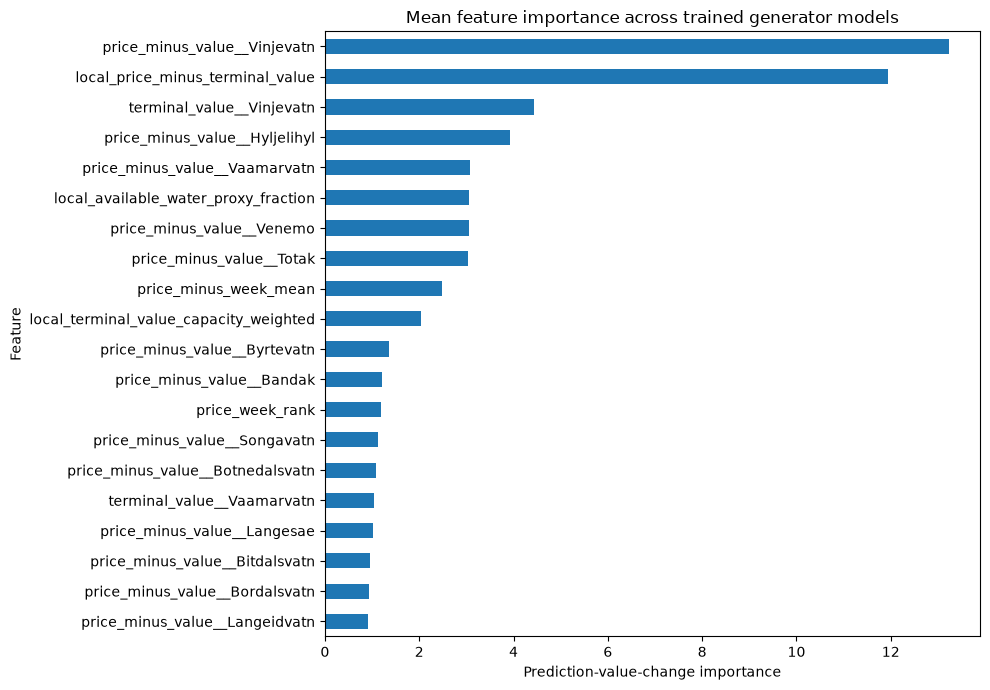

Complete notebook runtime: 21.1 minutes


In [ ]:
if importance_rows:
    import matplotlib.pyplot as plt
    importance_table = pd.DataFrame(importance_rows)
    importance_table.to_csv(RUN_DIRECTORY / "feature_importance_all.csv", index=False)
    top = importance_table.groupby("feature")["importance"].mean().nlargest(20).sort_values()
    fig, ax = plt.subplots(figsize=(10, 7))
    top.plot.barh(ax=ax)
    ax.set(title="Mean feature importance across trained generator models",
           xlabel="Prediction-value-change importance", ylabel="Feature")
    fig.tight_layout()
    fig.savefig(RUN_DIRECTORY / "feature_importance.png", dpi=150)
    plt.show()
if RUN_DIRECTORY is not None:
    run_summary["total_seconds"] = perf_counter() - NOTEBOOK_STARTED
    write_json(RUN_DIRECTORY / "run.json", run_summary)
    print(f"Complete notebook runtime: {run_summary['total_seconds'] / 60:.1f} minutes")
else:
    print("No training results yet. Change RUN_MODE yourself when ready.")